In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.interpolate import make_smoothing_spline
from scipy.interpolate import SmoothBivariateSpline

In [2]:
oae = xr.open_dataset("c:\\Users\\junsu\\my_project\\data\\OAE_efficiency_maps_alltime.nc")

oae_df = oae.to_dataframe()
oae_df = oae_df.reset_index().pivot(
    index="N_month", columns=["TLAT", "TLONG", "season"], values="OAE_efficiency"
)
oae_df.dropna(axis=1, how="all", inplace=True)
oae_diffed = oae_df - oae_df.shift().fillna(0)

## Empirical Analysis

In [3]:
oae_diffed = oae_diffed.loc[2:]

In [4]:
X_t0 = oae_diffed.iloc[:-1].to_numpy().flatten()
X_t1 = oae_diffed.iloc[1:].to_numpy().flatten()
finite_mask = np.isfinite(X_t0) & np.isfinite(X_t1)

In [5]:
cal_month = (
    oae_diffed.index.to_numpy()[:,np.newaxis] + oae_diffed.columns.get_level_values(2).map({"January": 1, "April": 4, "July": 7, "October": 10}).to_numpy()[np.newaxis,:]
)[:-1].flatten() % 12
season = np.abs(cal_month - 6)
season = 2 * season / season.max() - 1

In [6]:
latitude_0 = np.tile(oae_diffed.columns.get_level_values(0).to_numpy(), len(oae_diffed) - 1)
longitude_0 = np.tile(oae_diffed.columns.get_level_values(1).to_numpy(), len(oae_diffed) - 1)

latitude = latitude_0.round(1)
longitude = longitude_0.round(1)

time = np.repeat(oae_diffed.index.to_numpy()[:-1], len(oae_diffed.columns))
time = time / time.max()

In [7]:
a_bound = [0, 1.5]
b_bound = [0, 100]
c_bound = [-5, 0]
d_bound = [-1, 1]
e_bound = [-0.5, 0.5]
f_bound = [-0.5, 0.5]

def ar_model(
        X: np.ndarray,
        a: float,
        b: float,
        c: float,
        d: float,
        e: float,
        f: float,
    ) -> np.ndarray:
    return (a / (1 + np.exp(b*(X[:, 0] + c))) + d + e*X[:, 1]) * X[:, 2] + f

unique_latitude = np.unique(latitude)
optimal_params = np.zeros((len(unique_latitude), 6))

residuals = np.full_like(X_t1, np.nan, dtype=np.float64)
r_sq = np.zeros(len(unique_latitude))

popt = [1, 1, -0.5, 0, 0, 0]
for i, lat in enumerate(unique_latitude):
    print(f"Fitting for latitude = {lat:.1f}")
    lat_bw = 1.0
    mask = (lat - lat_bw <= latitude) & (latitude <= lat + lat_bw) & finite_mask
    X = np.column_stack((time[mask], season[mask], X_t0[mask]))
    popt, pcov = curve_fit(
        ar_model,
        X,
        X_t1[mask],
        p0=popt,
        bounds=(
            [a_bound[0], b_bound[0], c_bound[0], d_bound[0], e_bound[0], f_bound[0]],
            [a_bound[1], b_bound[1], c_bound[1], d_bound[1], e_bound[1], f_bound[1]],
        ),
    )
    optimal_params[i] = popt
    residuals[mask] = X_t1[mask] - ar_model(X, *popt)
    ss_res = np.sum(residuals[mask]**2)
    ss_tot = np.sum((X_t1[mask] - np.mean(X_t1[mask]))**2)
    r_sq[i] = 1 - (ss_res / ss_tot)

Fitting for latitude = -78.2
Fitting for latitude = -77.6
Fitting for latitude = -77.1
Fitting for latitude = -76.5
Fitting for latitude = -76.0
Fitting for latitude = -75.5
Fitting for latitude = -74.9
Fitting for latitude = -74.4
Fitting for latitude = -73.9
Fitting for latitude = -73.3
Fitting for latitude = -72.8
Fitting for latitude = -72.3
Fitting for latitude = -71.7
Fitting for latitude = -71.2
Fitting for latitude = -70.7
Fitting for latitude = -70.1
Fitting for latitude = -69.6
Fitting for latitude = -69.1
Fitting for latitude = -68.5
Fitting for latitude = -68.0
Fitting for latitude = -67.5
Fitting for latitude = -66.9
Fitting for latitude = -66.4
Fitting for latitude = -65.9
Fitting for latitude = -65.3
Fitting for latitude = -64.8
Fitting for latitude = -64.3
Fitting for latitude = -63.7
Fitting for latitude = -63.2
Fitting for latitude = -62.7
Fitting for latitude = -62.1
Fitting for latitude = -61.6
Fitting for latitude = -61.1
Fitting for latitude = -60.5
Fitting for la

In [8]:
lam = 2000
optimal_param_0_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 0], lam=lam)
optimal_param_1_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 1], lam=lam)
optimal_param_2_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 2], lam=lam)
optimal_param_3_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 3], lam=lam)
optimal_param_4_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 4], lam=lam)
optimal_param_5_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 5], lam=lam)

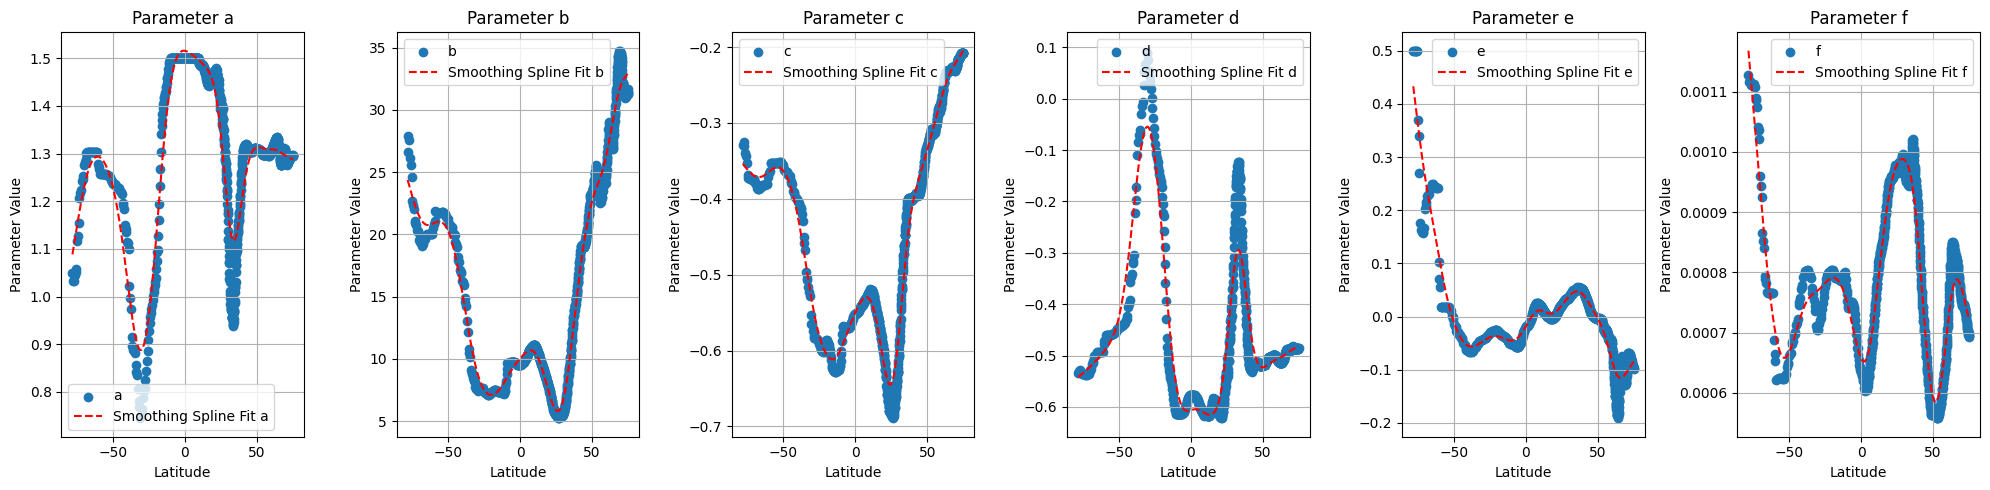

In [9]:
fig, ax = plt.subplots(1, 6, figsize=(20, 5))

ax[0].scatter(unique_latitude, optimal_params[:, 0], label="a")
ax[0].plot(unique_latitude, optimal_param_0_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit a')
ax[0].set_title("Parameter a")

ax[1].scatter(unique_latitude, optimal_params[:, 1], label="b")
ax[1].plot(unique_latitude, optimal_param_1_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit b')
ax[1].set_title("Parameter b")

ax[2].scatter(unique_latitude, optimal_params[:, 2], label="c")
ax[2].plot(unique_latitude, optimal_param_2_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit c')
ax[2].set_title("Parameter c")

ax[3].scatter(unique_latitude, optimal_params[:, 3], label="d")
ax[3].plot(unique_latitude, optimal_param_3_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit d')
ax[3].set_title("Parameter d")

ax[4].scatter(unique_latitude, optimal_params[:, 4], label="e")
ax[4].plot(unique_latitude, optimal_param_4_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit e')
ax[4].set_title("Parameter e")

ax[5].scatter(unique_latitude, optimal_params[:, 5], label="f")
ax[5].plot(unique_latitude, optimal_param_5_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit f')
ax[5].set_title("Parameter f")

for i in range(6):
    ax[i].set_xlabel("Latitude")
    ax[i].set_ylabel("Parameter Value")
    ax[i].grid(True)
    ax[i].legend()
plt.tight_layout()
plt.show()

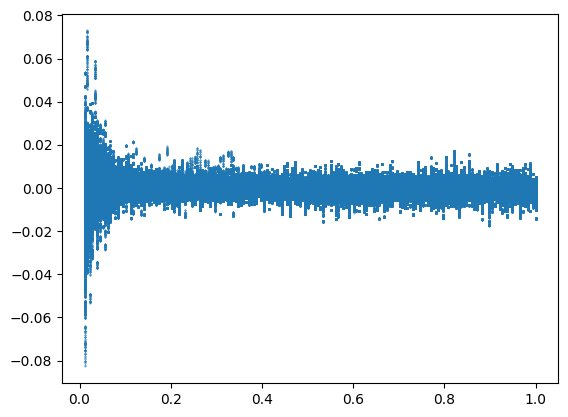

In [10]:
plt.scatter(time, residuals, s=0.1)

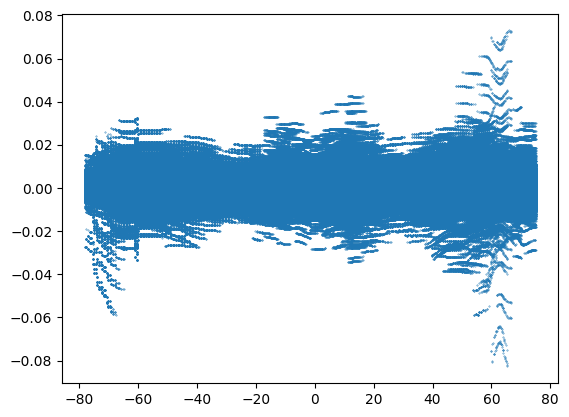

In [11]:
plt.scatter(latitude, residuals, s=0.1)

In [12]:
resd_mean_by_lat = pd.Series(residuals, index=latitude).groupby(latitude).mean()
resd_mean_by_lon = pd.Series(residuals, index=longitude).groupby(longitude).mean()
resd_mean_by_time = pd.Series(residuals, index=time).groupby(time).mean()

resd_std_by_lat = pd.Series(residuals, index=latitude).groupby(latitude).std()
resd_std_by_lon = pd.Series(residuals, index=longitude).groupby(longitude).std()
resd_std_by_time = pd.Series(residuals, index=time).groupby(time).std()

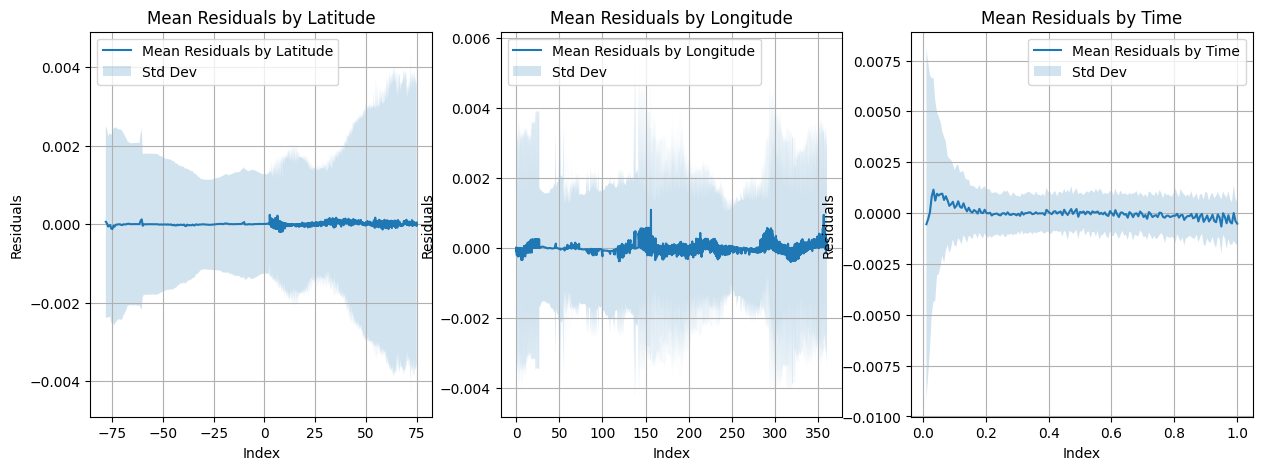

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(unique_latitude, resd_mean_by_lat, label='Mean Residuals by Latitude')
ax[0].fill_between(unique_latitude, resd_mean_by_lat - resd_std_by_lat, resd_mean_by_lat + resd_std_by_lat, alpha=0.2, label='Std Dev')
ax[0].set_title("Mean Residuals by Latitude")
ax[1].plot(np.unique(longitude), resd_mean_by_lon, label='Mean Residuals by Longitude')
ax[1].fill_between(np.unique(longitude), resd_mean_by_lon - resd_std_by_lon, resd_mean_by_lon + resd_std_by_lon, alpha=0.2, label='Std Dev')
ax[1].set_title("Mean Residuals by Longitude")
ax[2].plot(np.unique(time), resd_mean_by_time, label='Mean Residuals by Time')
ax[2].fill_between(np.unique(time), resd_mean_by_time - resd_std_by_time, resd_mean_by_time + resd_std_by_time, alpha=0.2, label='Std Dev')
ax[2].set_title("Mean Residuals by Time")
for i in range(3):
    ax[i].set_xlabel("Index")
    ax[i].set_ylabel("Residuals")
    ax[i].grid(True)
    ax[i].legend()

In [19]:
residuals

array([-0.00258407, -0.00020708,  0.0020917 , ..., -0.00525285,
        0.00046796, -0.00620945], shape=(55710396,))

In [20]:
time

array([0.01123596, 0.01123596, 0.01123596, ..., 1.        , 1.        ,
       1.        ], shape=(55710396,))

In [21]:
latitude

array([-78.2, -78.2, -78.2, ...,  75. ,  75. ,  75. ], shape=(55710396,))

In [42]:
import numpy as np
from sklearn.neighbors import KDTree
from sklearn.model_selection import train_test_split

def smooth_variance_scatter_kde_holdout(X, Y, residuals, sigma_candidates, test_size=0.2, rng=42, k=30):
    coords = np.column_stack([X, Y])
    res2 = residuals**2
    
    # Split once into train / validation
    train_idx, val_idx = train_test_split(np.arange(len(coords)), test_size=test_size, random_state=rng)
    
    best_sigma = None
    best_score = np.inf

    # Pre-build KDTree on training set
    tree = KDTree(coords[train_idx])
    
    for sigma in sigma_candidates:
        # Query k neighbors for validation points
        dists, idxs = tree.query(coords[val_idx], k=min(k, len(train_idx)))
        weights = np.exp(-0.5 * (dists / sigma)**2)
        weights /= weights.sum(axis=1, keepdims=True)
        
        var_hat = np.sum(weights * res2[train_idx][idxs], axis=1)
        std_hat = np.sqrt(var_hat)
        
        # Score = mean absolute error between predicted std and actual |residual|
        score = np.mean(np.abs(std_hat - np.abs(residuals[val_idx])))
        
        if score < best_score:
            best_score = score
            best_sigma = sigma

    # Final smoothing with best sigma, using *all* data
    tree = KDTree(coords)
    dists, idxs = tree.query(coords, k=min(k, len(coords)))
    weights = np.exp(-0.5 * (dists / best_sigma)**2)
    weights /= weights.sum(axis=1, keepdims=True)
    var_smooth = np.sum(weights * res2[idxs], axis=1)
    std_hat = np.sqrt(var_smooth)
    
    return coords[:,0], coords[:,1], var_smooth, std_hat, best_sigma

In [ ]:
Xi, Yi, var_smooth, std_hat, best_sigma = smooth_variance_scatter_kde_holdout(
    time, latitude, residuals, sigma_candidates=np.linspace(0.001,1,10)
)
print("Chosen sigma:", best_sigma)

KeyboardInterrupt: 

In [32]:
import plotly.graph_objects as go
import numpy as np

# Xi, Yi, var_smooth from your smooth_variance_scattered function
# If you want standard deviation instead, use np.sqrt(var_smooth)

fig = go.Figure(data=[go.Surface(
    z=std_hat,
    x=Xi,
    y=Yi,
    colorscale='Viridis'
)])

fig.update_layout(
    title='Smoothed Variance Surface',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Variance'
    ),
    autosize=True,
    width=800,
    height=700,
)

fig.show()